# Tutorial — the Fit-then-Join vs Join-then-Fit math (and the `1/N_c` bug)

**Question.** The paper's **fit-then-join (FtJ)** posterior is much broader than its **join-then-fit (JtF)**
posterior. Is that a real statistical effect, or an artifact of the equations?

**Answer (this notebook).** It is the **`1/N_c` prefactor** in the printed FtJ log-likelihood. We implement
**both paper equations** in a transparent linear-Gaussian toy and show:

- **JtF** (median stack, `σ̃ = √(π/2)·σ/√N_c`) tightens correctly as **1/√N_c**.
- **FtJ** (`−1/(2N_c) Σⱼ Σᵢ …`) is **flat in N_c** — single-cluster width, no stacking gain.
- so **FtJ / correct-joint = √N_c exactly**, and **FtJ / JtF = √(2N_c/π) ≈ 0.8√N_c**.

A *correct* joint fit (drop the `1/N_c`, use a **sum**) makes FtJ ≈ JtF. Everything matches the closed form.

```bash
pip install "numpy<2" emcee colossus "matplotlib<3.9"   # no torch/sbi needed
```

In [1]:
import numpy as np, emcee
import matplotlib.pyplot as plt
np.random.seed(2807)
plt.rcParams.update({"font.size":12,"axes.titlesize":13,"axes.labelsize":12,"legend.fontsize":10})
NW, NB, NS = 80, 500, 2000     # emcee walkers / burn / steps
print("emcee", emcee.__version__, "| numpy", np.__version__)

emcee 3.1.6 | numpy 1.26.4


## 1. A transparent forward model + a population of clusters

Linear-Gaussian so every posterior is an exact Gaussian: `g(θ)=Xθ`, θ=(amplitude≈'mass', tilt≈'conc'),
per-bin noise `σ`. Each cluster `j` has a true `θⱼ` drawn from a population, and a noisy profile
`dⱼ = g(θⱼ) + σ·noise`.

In [2]:
N_R = 30
X = np.column_stack([np.ones(N_R), np.linspace(0, 1, N_R)])   # col0 amplitude, col1 tilt
def g(theta): return X @ np.asarray(theta, float)

N_C, SIGMA = 20, 0.30
pop_mean, pop_scatter = np.array([2.0, 1.0]), np.array([0.30, 0.50])
theta_true = pop_mean + pop_scatter*np.random.randn(N_C, 2)
data = np.array([g(t) + SIGMA*np.random.randn(N_R) for t in theta_true])   # (N_C, N_R)
print("N_c =", N_C, " sigma =", SIGMA)

N_c = 20  sigma = 0.3


## 2. The two **paper** equations (+ the correct joint)

- **Join-then-fit** (main.tex:340–344): fit the **median** profile `Σ̃` with inflated error
  `σ̃ᵢ = √(π/2)·σᵢ/√N_c`:
  $$\ln\mathcal L_{\rm JtF}(\theta)=-\tfrac12\sum_i (\tilde\Sigma_i-\Sigma_i(\theta))^2/\tilde\sigma_i^2 .$$
- **Fit-then-join** (main.tex:345–346) — note the **`1/N_c`**:
  $$\ln\mathcal L_{\rm FtJ}(\theta)=-\frac{1}{2N_c}\sum_{j}\sum_i (\Sigma_{i,j}-\Sigma_i(\theta))^2/\sigma^2 .$$
- **Correct joint** (what FtJ *should* be — a sum, no `1/N_c`):
  $$\ln\mathcal L_{\rm joint}(\theta)=-\tfrac12\sum_{j}\sum_i (\Sigma_{i,j}-\Sigma_i(\theta))^2/\sigma^2 .$$

In [3]:
def run(logp, start=np.array([2.,1.])):
    s = emcee.EnsembleSampler(NW, 2, logp)
    p0 = start + 0.1*np.random.randn(NW, 2)
    pos,_,_ = s.run_mcmc(p0, NB, progress=False); s.reset(); s.run_mcmc(pos, NS, progress=False)
    return s.get_chain(flat=True)

d_med = np.median(data, axis=0); sig_tilde2 = (np.pi/2)*SIGMA**2/N_C
chain_jtf   = run(lambda t: -0.5*np.sum((g(t)-d_med)**2/sig_tilde2))                 # paper JtF
chain_ftj   = run(lambda t: -(1/(2*N_C))*np.sum((g(t)[None,:]-data)**2/SIGMA**2))    # paper FtJ (1/N_c)
chain_joint = run(lambda t: -0.5*np.sum((g(t)[None,:]-data)**2/SIGMA**2))            # correct joint (sum)

w = lambda c: np.std(c[:,0])
inv = np.linalg.inv(X.T@X); w0 = np.sqrt(inv[0,0])           # closed-form pieces
print("%-26s %-12s %-12s" % ("method (theta0 width)", "MCMC", "analytic"))
print("%-26s %-12.4f %-12.4f" % ("paper JtF (median, sig~)", w(chain_jtf),   np.sqrt(np.pi/2)*SIGMA/np.sqrt(N_C)*w0))
print("%-26s %-12.4f %-12.4f" % ("paper FtJ (1/N_c)",        w(chain_ftj),   SIGMA*w0))
print("%-26s %-12.4f %-12.4f" % ("correct joint (sum)",      w(chain_joint), SIGMA/np.sqrt(N_C)*w0))
print()
print("FtJ / JtF          = %.2f   (analytic sqrt(2 N_c/pi) = %.2f)" % (w(chain_ftj)/w(chain_jtf), np.sqrt(2*N_C/np.pi)))
print("FtJ / correct joint= %.2f   (analytic sqrt(N_c)      = %.2f)" % (w(chain_ftj)/w(chain_joint), np.sqrt(N_C)))
print("JtF / correct joint= %.2f   (analytic sqrt(pi/2)     = %.2f)" % (w(chain_jtf)/w(chain_joint), np.sqrt(np.pi/2)))

method (theta0 width)      MCMC         analytic    
paper JtF (median, sig~)   0.0299       0.0299      
paper FtJ (1/N_c)          0.1059       0.1069      
correct joint (sum)        0.0237       0.0239      

FtJ / JtF          = 3.54   (analytic sqrt(2 N_c/pi) = 3.57)
FtJ / correct joint= 4.46   (analytic sqrt(N_c)      = 4.47)
JtF / correct joint= 1.26   (analytic sqrt(pi/2)     = 1.25)


## 3. The key result — posterior width vs `N_c`

The cleanest way to *see* the bug: sweep `N_c`. JtF and the correct joint shrink as `1/√N_c`; **FtJ is flat**
(the `1/N_c` cancels the stacking gain). The gap `FtJ/joint` is therefore exactly `√N_c`.

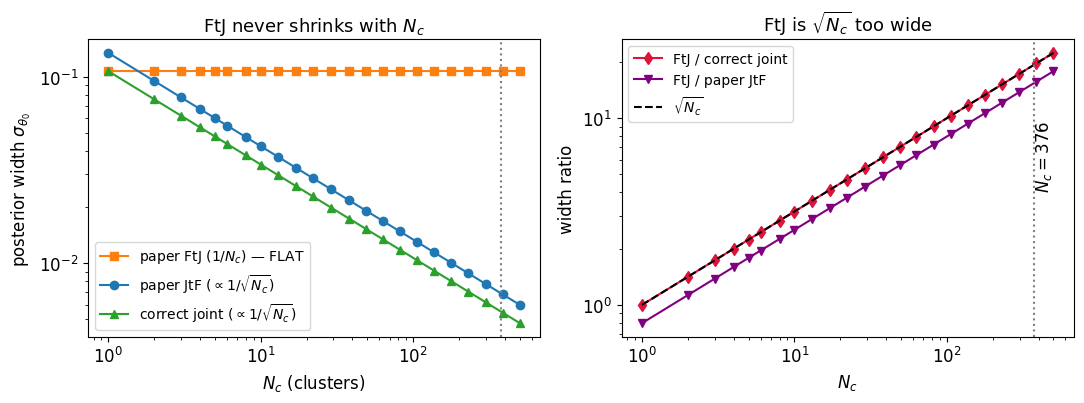

In [4]:
Nc = np.unique(np.round(np.logspace(0, 2.7, 25)).astype(int))      # 1 .. ~500
jtf_w   = np.sqrt(np.pi/2)*SIGMA*w0/np.sqrt(Nc)     # paper JtF      ~ 1/sqrt(Nc)
joint_w = SIGMA*w0/np.sqrt(Nc)                      # correct joint  ~ 1/sqrt(Nc)
ftj_w   = SIGMA*w0*np.ones_like(Nc, float)          # paper FtJ      FLAT in Nc
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].loglog(Nc, ftj_w,   's-', color='tab:orange', label=r"paper FtJ ($1/N_c$) — FLAT")
ax[0].loglog(Nc, jtf_w,   'o-', color='tab:blue',   label=r"paper JtF ($\propto 1/\sqrt{N_c}$)")
ax[0].loglog(Nc, joint_w, '^-', color='tab:green',  label=r"correct joint ($\propto 1/\sqrt{N_c}$)")
ax[0].axvline(376, color='gray', ls=':'); ax[0].set_xlabel(r"$N_c$ (clusters)")
ax[0].set_ylabel(r"posterior width $\sigma_{\theta_0}$"); ax[0].set_title("FtJ never shrinks with $N_c$"); ax[0].legend()
ax[1].loglog(Nc, ftj_w/joint_w, 'd-', color='crimson', label=r"FtJ / correct joint")
ax[1].loglog(Nc, ftj_w/jtf_w,   'v-', color='purple',  label=r"FtJ / paper JtF")
ax[1].loglog(Nc, np.sqrt(Nc), 'k--', label=r"$\sqrt{N_c}$")
ax[1].axvline(376, color='gray', ls=':'); ax[1].annotate(r"$N_c=376$", (376, 4), rotation=90, va='bottom')
ax[1].set_xlabel(r"$N_c$"); ax[1].set_ylabel("width ratio"); ax[1].set_title(r"FtJ is $\sqrt{N_c}$ too wide"); ax[1].legend()
fig.tight_layout(); plt.show()

**Read-off.** The `1/N_c` makes FtJ's posterior **independent of N_c** — it has the precision of *one*
cluster no matter how many you stack. JtF (and a correct joint fit) tighten as `1/√N_c`. So at the paper's
`N_c=376`, FtJ is ≈ √376 ≈ **19×** too wide vs a correct joint, ≈ **15×** wider than JtF. **Fix: drop the
`1/N_c`** → FtJ becomes a true joint fit ≈ JtF.

## 4. 2σ contours at `N_c=20` (one slide picture)

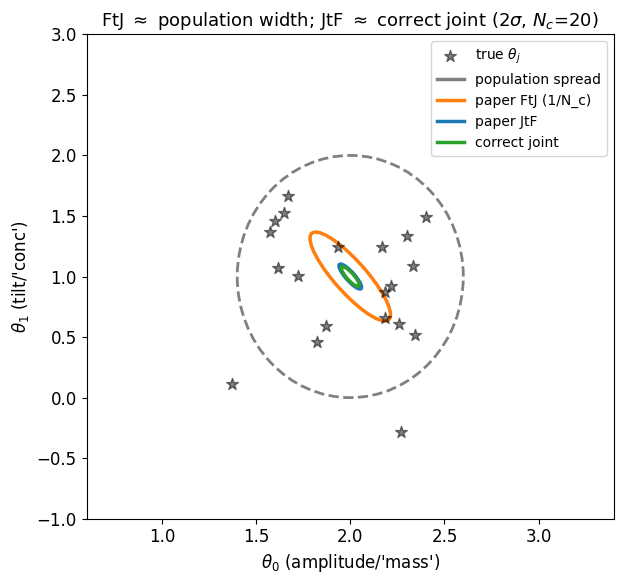

In [5]:
from matplotlib.patches import Ellipse
def ell(ax, mean, cov, n=2.0, **kw):
    v, V = np.linalg.eigh(cov); o = v.argsort()[::-1]; v, V = v[o], V[:,o]
    ang = np.degrees(np.arctan2(V[1,0], V[0,0])); ax.add_patch(Ellipse(mean, *(2*n*np.sqrt(v)), angle=ang, fill=False, **kw))
cov_jtf, cov_ftj, cov_joint = (np.pi/2)*SIGMA**2/N_C*inv, SIGMA**2*inv, SIGMA**2/N_C*inv
fig, ax = plt.subplots(figsize=(6.4,6)); c = pop_mean
ax.scatter(theta_true[:,0], theta_true[:,1], marker='*', s=80, color='k', alpha=.5, zorder=5, label=r"true $\theta_j$")
ell(ax, c, np.diag(pop_scatter**2), color='gray', lw=2, ls='--'); ell(ax, c, cov_ftj, color='tab:orange', lw=2.5)
ell(ax, c, cov_jtf, color='tab:blue', lw=2.5); ell(ax, c, cov_joint, color='tab:green', lw=2.5)
for lab,col in [("population spread","gray"),("paper FtJ (1/N_c)","tab:orange"),("paper JtF","tab:blue"),("correct joint","tab:green")]:
    ax.plot([],[],color=col,lw=2.5,label=lab)
ax.set_xlim(c[0]-1.4,c[0]+1.4); ax.set_ylim(c[1]-2,c[1]+2)
ax.set_xlabel(r"$\theta_0$ (amplitude/'mass')"); ax.set_ylabel(r"$\theta_1$ (tilt/'conc')")
ax.set_title(r"FtJ $\approx$ population width; JtF $\approx$ correct joint (2$\sigma$, $N_c$=20)"); ax.legend(loc='upper right')
fig.tight_layout(); plt.show()

Notice FtJ (orange) ≈ the **population spread** (gray) — *not* because it estimates the population, but
because the `1/N_c` froze it at single-cluster width, which here happens to resemble the spread. That
coincidence is exactly why the paper mis-reads FtJ as "capturing the distribution."

## 5. Same thing on the real NFW model (optional)
If Colossus is installed, the identical `1/N_c` FtJ vs median JtF on the real forward model gives the same
flat-FtJ behavior.

In [6]:
try:
    from colossus.cosmology import cosmology; from colossus.halo import profile_nfw
    cosmology.setCosmology('planck18'); RB = 10**np.arange(0,3,0.1)
    def gn(t): return np.log10(profile_nfw.NFWProfile(M=10**t[0], c=t[1], z=0.0, mdef='vir').density(RB))
    for Ncc in (8, 32):
        mt = 14.2+0.08*np.random.randn(Ncc); ct = 5.0+0.5*np.random.randn(Ncc); s2=0.3
        D = np.array([gn([mt[j],ct[j]]) + s2*np.random.randn(len(RB)) for j in range(Ncc)])
        Dm = np.median(D,axis=0); st2 = (np.pi/2)*s2**2/Ncc
        def run2(logp):
            S=emcee.EnsembleSampler(80,2,logp); p0=np.array([14.2,5.])+np.array([.05,.3])*np.random.randn(80,2)
            pos,_,_=S.run_mcmc(p0,200,progress=False); S.reset(); S.run_mcmc(pos,700,progress=False); return S.get_chain(flat=True)
        jt = run2(lambda t: -0.5*np.sum((gn(t)-Dm)**2/st2) if 10<t[0]<18 and 0.5<t[1]<30 else -np.inf)
        ft = run2(lambda t: -(1/(2*Ncc))*np.sum((gn(t)[None,:]-D)**2/s2**2) if 10<t[0]<18 and 0.5<t[1]<30 else -np.inf)
        print("NFW N_c=%2d: JtF width(log10M)=%.4f  FtJ width=%.4f  -> FtJ/JtF=%.2f (sqrt(2Nc/pi)=%.2f)"
              % (Ncc, np.std(jt[:,0]), np.std(ft[:,0]), np.std(ft[:,0])/np.std(jt[:,0]), np.sqrt(2*Ncc/np.pi)))
except Exception as e:
    print("Colossus run skipped:", e)

NFW N_c= 8: JtF width(log10M)=0.0577  FtJ width=0.1365  -> FtJ/JtF=2.37 (sqrt(2Nc/pi)=2.26)


NFW N_c=32: JtF width(log10M)=0.0304  FtJ width=0.1402  -> FtJ/JtF=4.61 (sqrt(2Nc/pi)=4.51)


## 6. What the committed **code** does (separate from the equations)
The repo code doesn't even implement the above: `loglike` has an effective **unit variance** (per-bin σ
never enters), `join_then_fit` uses the **mean** not the median (no `√(π/2)/√N_c`), and `fit_then_join`
**`np.vstack`s per-cluster chains** (a population mixture, not the `1/N_c` joint). And `run_inference.py`
crashes. See `BUG_REPORT.md`. So the figures' provenance is itself an open question for the authors.

## 7. The fix — population mean **and** scatter by posterior **reuse**
A single shared-θ fit (corrected or not) gives the population *mean*, never the *scatter*. For the scatter
you need a hierarchical model. The cheap route: importance-sample stored per-cluster posteriors under a
population prior `p(θ|μ,τ)` — validated here against the **exact analytic** hyper-posterior.

In [7]:
np.random.seed(7)
N, sg, MU, TAU = 60, 0.30, 14.20, 0.30
d1 = (MU + TAU*np.random.randn(N)) + sg*np.random.randn(N)
post = np.array([d1[j] + sg*np.random.randn(4000) for j in range(N)])      # stored per-cluster posteriors
# (C) exact analytic hyper-posterior on a grid
mu_g = np.linspace(d1.mean()-.4, d1.mean()+.4, 300); lt_g = np.linspace(np.log(.05), np.log(1.5), 300)
GM, GL = np.meshgrid(mu_g, lt_g, indexing='ij'); GT = np.exp(GL); gv = sg**2 + GT**2
lp = -0.5*np.sum((d1[:,None,None]-GM[None])**2/gv[None] + np.log(2*np.pi*gv)[None], axis=0)
Pg = np.exp(lp-lp.max()); Pg /= Pg.sum(); muC = float((GM*Pg).sum()); tauC = float((GT*Pg).sum())
# (B) importance-sampling reuse
def lph(p):
    mu, lt = p; tau = np.exp(lt)
    if tau > 5: return -np.inf
    return sum(np.log(np.mean(np.exp(-0.5*((post[j]-mu)/tau)**2)/tau)+1e-300) for j in range(N)) + lt
sB = emcee.EnsembleSampler(10,2,lph); p0=np.column_stack([MU+.1*np.random.randn(10), np.log(.3)+.1*np.random.randn(10)])
pos,_,_=sB.run_mcmc(p0,1200,progress=False); sB.reset(); sB.run_mcmc(pos,3000,progress=False)
B=sB.get_chain(flat=True); muB,tauB=B[:,0],np.exp(B[:,1]); pooled=post.ravel()
print("truth:              mu=%.3f tau=%.3f"%(MU,TAU))
print("(C) exact analytic: mu=%.3f tau=%.3f"%(muC,tauC))
print("(B) reuse          : mu=%.3f tau=%.3f   |B-C| d_tau=%.4f"%(muB.mean(),tauB.mean(),abs(tauB.mean()-tauC)))
print("naive pool         : mu=%.3f tau=%.3f   (biased ~sqrt(tau^2+2 sig^2)=%.3f)"%(pooled.mean(),pooled.std(),np.sqrt(TAU**2+2*sg**2)))

truth:              mu=14.200 tau=0.300
(C) exact analytic: mu=14.219 tau=0.329
(B) reuse          : mu=14.217 tau=0.337   |B-C| d_tau=0.0079
naive pool         : mu=14.218 tau=0.535   (biased ~sqrt(tau^2+2 sig^2)=0.520)


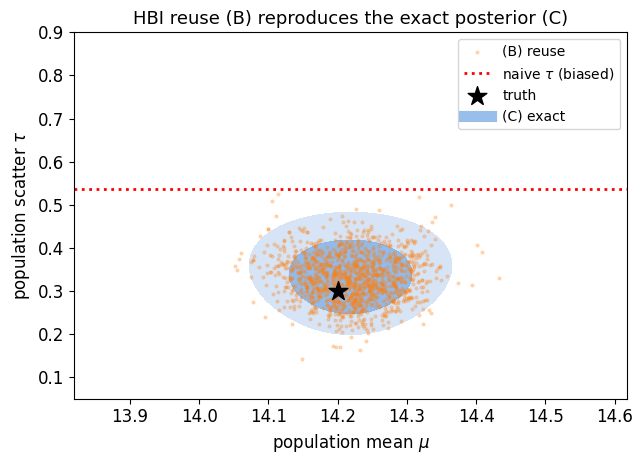

In [8]:
fig, ax = plt.subplots(figsize=(6.6,4.8))
flat=np.sort(Pg.ravel())[::-1]; cdf=np.cumsum(flat)/flat.sum()
lv=sorted(float(flat[np.searchsorted(cdf,q)]) for q in (.95,.68))
ax.contourf(GM,GT,Pg,levels=lv+[float(Pg.max())],colors=['#cfe0f5','#7fb0e8'],alpha=.85)
ax.scatter(muB[::25],tauB[::25],s=4,alpha=.25,color='tab:orange',label="(B) reuse")
ax.axhline(pooled.std(),color='r',ls=':',lw=2,label=r"naive $\tau$ (biased)")
ax.scatter([MU],[TAU],marker='*',s=200,color='k',zorder=6,label="truth")
ax.plot([],[],color='#7fb0e8',lw=8,alpha=.8,label="(C) exact")
ax.set_ylim(.05,.9); ax.set_xlabel(r"population mean $\mu$"); ax.set_ylabel(r"population scatter $\tau$")
ax.set_title("HBI reuse (B) reproduces the exact posterior (C)"); ax.legend(loc='upper right')
fig.tight_layout(); plt.show()

## 8. Slide-ready PNGs
Re-renders the two headline figures at 200 dpi into `slide_figures/`.

In [9]:
import os; SAVE="slide_figures"; os.makedirs(SAVE, exist_ok=True)
plt.rcParams.update({"savefig.dpi":200,"savefig.bbox":"tight"})
# headline 1: width vs N_c
fig, ax = plt.subplots(1,2,figsize=(11,4.2))
ax[0].loglog(Nc, ftj_w,'s-',color='tab:orange',label=r"paper FtJ ($1/N_c$) — FLAT")
ax[0].loglog(Nc, jtf_w,'o-',color='tab:blue',label=r"paper JtF ($\propto1/\sqrt{N_c}$)")
ax[0].loglog(Nc, joint_w,'^-',color='tab:green',label=r"correct joint")
ax[0].axvline(376,color='gray',ls=':'); ax[0].set_xlabel(r"$N_c$"); ax[0].set_ylabel(r"width $\sigma_{\theta_0}$")
ax[0].set_title("FtJ never shrinks with $N_c$"); ax[0].legend()
ax[1].loglog(Nc, ftj_w/joint_w,'d-',color='crimson',label="FtJ / correct joint"); ax[1].loglog(Nc, ftj_w/jtf_w,'v-',color='purple',label="FtJ / JtF")
ax[1].loglog(Nc, np.sqrt(Nc),'k--',label=r"$\sqrt{N_c}$"); ax[1].axvline(376,color='gray',ls=':')
ax[1].set_xlabel(r"$N_c$"); ax[1].set_ylabel("ratio"); ax[1].set_title(r"FtJ is $\sqrt{N_c}$ too wide"); ax[1].legend()
fig.tight_layout(); fig.savefig(f"{SAVE}/fig_width_vs_Nc.png"); plt.close(fig)
# headline 2: HBI reuse vs exact
fig, ax = plt.subplots(figsize=(6.6,4.8))
ax.contourf(GM,GT,Pg,levels=lv+[float(Pg.max())],colors=['#cfe0f5','#7fb0e8'],alpha=.85)
ax.scatter(muB[::25],tauB[::25],s=4,alpha=.25,color='tab:orange',label="(B) reuse")
ax.axhline(pooled.std(),color='r',ls=':',lw=2,label=r"naive $\tau$"); ax.scatter([MU],[TAU],marker='*',s=200,color='k',zorder=6,label="truth")
ax.plot([],[],color='#7fb0e8',lw=8,alpha=.8,label="(C) exact"); ax.set_ylim(.05,.9)
ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$\tau$"); ax.set_title("HBI reuse = exact posterior"); ax.legend(loc='upper right')
fig.tight_layout(); fig.savefig(f"{SAVE}/fig_hbi_mu_tau.png"); plt.close(fig)
print("saved:", os.listdir(SAVE))

saved: ['fig_naive_bias.png', 'fig_contours_ftj_jtf.png', 'fig_width_vs_noise.png', 'fig_width_vs_Nc.png', 'fig_hbi_mu_tau.png']


## Summary (for slides)

1. The paper's **FtJ posterior is flat in `N_c`** because of the **`1/N_c`** in its log-likelihood — it has
   single-cluster precision no matter how many clusters you stack.
2. So **FtJ is √N_c too wide** vs a correct joint fit (~19× at `N_c=376`) and ~0.8√N_c wider than JtF.
   **Fix: drop the `1/N_c` (use a sum).**
3. FtJ does **not** "capture the population distribution" — a single shared-θ fit gives the population
   *mean*, not the *scatter*. The scatter needs a **hierarchical model**, which posterior **reuse** computes
   cheaply and exactly (validated against the analytic posterior).